In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
import cmasher as cmr

from models import CondSM

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 9,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_gm_0/sm_gm_MSE.pth', weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], dropout_p=state_dict['dropout'], batch_norm=state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
print('model loaded')

cuda
model loaded


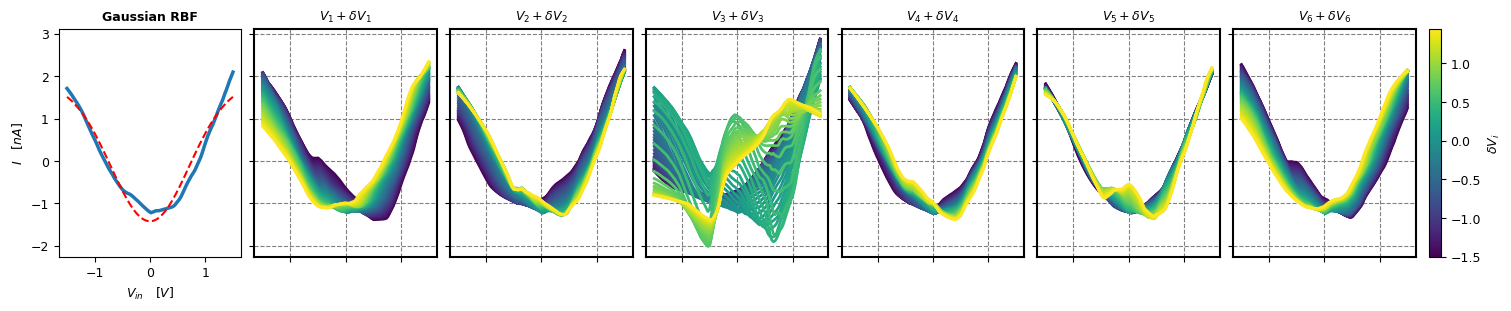

In [26]:
def z_scored(x):
    
    z = (x - x.mean()) / (x.std() + 1e-8) 
    
    return z

def target_function(x):

    return -torch.exp(-1*x**2)

opt_params = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_rbf_gaussian_vMB_0.npy', allow_pickle=True).item()
params = opt_params['params']

N = 100
v = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
funcs = []
"""for p_opt in params:
    c_v = torch.from_numpy(p_opt).float().expand(N, -1)
    #print(c_v)
    input_tensor = torch.cat([v, c_v], axis=1)
    out = model(input_tensor).detach().cpu().numpy()
    funcs.append(out[:, 0])
for i in range(len(funcs)):
    plt.plot(funcs[i])"""

#opt_param = params[5]
opt_param = np.array([-1.0018, -0.1320, -0.4861, -0.2575, -0.6513, -1.3980])
perturbations = torch.arange(-1.5, 1.5, 0.05)
num_voltages = model.layer_dims[0]
model.eval()
fig, ax = plt.subplots(nrows=1, ncols=num_voltages, figsize=(15, 3), sharey='row', sharex='col', constrained_layout=True)

cmap = plt.get_cmap('viridis')
#cmap = plt.get_cmap('cmr.redshift')
norm = plt.Normalize(vmin=perturbations[0], vmax=perturbations[-1])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

c_v = torch.from_numpy(opt_param).expand(N, -1).float()
input_tensor = torch.cat([v, c_v], axis=1)
with torch.no_grad():
    I = model(input_tensor).detach().cpu().numpy()
ax[0].plot(v, z_scored(I), lw=2.5)
ax[0].plot(v, z_scored(target_function(v)), c='r', lw=1.5, ls='dashed', zorder=5)
ax[0].set_ylabel(r'$I \quad [nA]$')
ax[0].set_xlabel(r'$V_{in} \quad [V]$')
ax[0].set_title(r'Gaussian RBF', fontweight='bold')

cbar = fig.colorbar(sm, ax=ax.ravel().tolist(), label=rf'$\delta V_i$', pad=0.01)

for i in range(1, num_voltages):
    for delta in perturbations:
        
        c_v = torch.from_numpy(opt_param).expand(N, -1).float()
        input_tensor = torch.cat([v, c_v], axis=1)
        input_tensor[:, i] += delta
        with torch.no_grad():
            I = model(input_tensor).detach().numpy()            

        def act_func(x):
            return -np.exp(-1 * x ** 2)
        ax[i].plot(v, z_scored(I), color=cmap(norm(delta)), lw=2.0)
        #ax[i].plot(v, z_scored(act_func(v)), c='k', alpha=.25, zorder=5)

        ax[i].tick_params(labelbottom=False)
        ax[i].set_title(rf'$V_{i} + \delta V_{i}$')
        
        #ax[0, i].set_facecolor('lightgrey')
        #ax[1, i].set_facecolor('lightgrey')

        ax[i].spines[:].set_linewidth(1.5)

        ax[i].tick_params(labelbottom=False)

        ax[i].tick_params(labelleft=False)

        ax[i].grid(True, which='both', c='gray', ls='dashed')

        
#plt.savefig('test.pdf', bbox_inches='tight')
plt.show()